# Applying AI Regulatory Guidelines (GDPR) in Model Development

## 📚 Learning Objectives

By completing this notebook, you will:
- Map core GDPR requirements (consent, data minimization, right to erasure, right to explanation) to concrete steps in an ML pipeline
- Enforce **consent** and **data minimization** on a raw customer dataset before training
- Handle a **right-to-erasure** (Art. 17) request: delete a person's data and retrain
- Produce a per-decision **explanation** (Art. 22 context) from a linear model
- Run an automated **compliance check** over the pipeline's artifacts

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Units 3 and 5 (privacy, data protection, governance) and Course 04 (AIAT 114) — Unit 3, whose linear model supplies the per-decision explanation required by Article 22.

**Used later in:** Course 12 (AIAT 126) — Unit 1, where consent and data-minimisation constraints shape what a project may collect.

---

This notebook covers practical activities from **Course 10, Unit 4**:
- Applying AI regulatory guidelines like GDPR to ensure compliance in model development

---

## Introduction

The **GDPR** (EU General Data Protection Regulation, 2018) is not an "AI law" — it is a *personal
data* law. But every ML pipeline trained on customer data is a personal-data processing system,
so GDPR applies from the first `read_csv`. Below we take one small pipeline through the four
requirements engineers hit most often.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## Part 1 — Baseline: a Pipeline *Before* the Compliance Review

First, a perfectly ordinary scikit-learn pipeline (mixed numeric + categorical features,
one-hot encoding, logistic regression). Nothing about it is GDPR-aware yet — this is the
"before" picture that Part 2 will make compliant.

In [1]:
# Baseline ML pipeline: train and evaluate an ordinary classifier on synthetic data.
# WHY: this is the "before compliance" system — Part 2 applies GDPR requirements to a
# pipeline just like this one.
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── Small synthetic dataset: two numeric features + one categorical ────────
rng = np.random.default_rng(123)
n = 600
x1 = rng.normal(size=n)
x2 = rng.normal(size=n)
color = rng.choice(['red', 'green', 'blue'], size=n)

# Label depends on the features (plus noise), so the model has something real to learn
y = ((x1 + 0.8*x2 + (color == 'red')*0.6 + rng.normal(scale=0.5, size=n)) > 0.2).astype(int)

df = pd.DataFrame({'x1': x1, 'x2': x2, 'color': color, 'y': y})
X = df.drop(columns=['y'])
y = df['y']

# ── Hold out a test set for honest evaluation ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# ── Preprocessing + model in one Pipeline: one-hot the categorical column ──
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['color']),
], remainder='passthrough')

clf = Pipeline([
    ('pre', pre),
    ('model', LogisticRegression(max_iter=1000))
])
clf.fit(X_train, y_train)

# ── Evaluate: accuracy + confusion matrix + per-class report ───────────────
y_pred = clf.predict(X_test)
print('accuracy:', accuracy_score(y_test, y_pred))
print('confusion matrix:', confusion_matrix(y_test, y_pred))
print('\nreport:', classification_report(y_test, y_pred))

accuracy: 0.9266666666666666
confusion matrix: [[70  5]
 [ 6 69]]

report:               precision    recall  f1-score   support

           0       0.92      0.93      0.93        75
           1       0.93      0.92      0.93        75

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



## Part 2 — GDPR in Practice for ML Pipelines

The four requirements engineers meet most often, and what each means in code:

| GDPR provision | Plain meaning | ML-pipeline practice |
|---|---|---|
| **Art. 6/7 — Lawful basis / consent** | You may only process data you have a legal basis for | Filter training data to records with `consent = True` |
| **Art. 5(1)(c) — Data minimization** | Collect/keep only what the purpose needs | Drop PII columns the model doesn't need; pseudonymize IDs |
| **Art. 17 — Right to erasure** | A person can demand their data be deleted | Delete their rows **and retrain** the model |
| **Art. 22 — Automated decisions** | People get safeguards + meaningful information about automated decisions | Per-decision explanations, human review path |

We now apply each one to a small "customer churn" pipeline with realistic PII.

In [2]:
# GDPR step 1+2 — CONSENT filtering and DATA MINIMIZATION on a raw customer table.
# WHY: the raw table contains PII the model must never see, and records without consent
# that must never enter training.
import hashlib

rng = np.random.default_rng(7)
N = 500

# ── Raw dataset as a company might actually store it (with PII) ────────────
first = rng.choice(['Sara', 'Omar', 'Lina', 'Faisal', 'Nora', 'Adam'], N)
raw = pd.DataFrame({
    'name'       : [f"{f} Al-{i:03d}" for i, f in enumerate(first)],          # PII
    'email'      : [f"user{i:03d}@example.com" for i in range(N)],             # PII
    'national_id': rng.integers(10**9, 10**10, N).astype(str),                 # PII (sensitive!)
    'consent'    : rng.random(N) < 0.85,          # 85% of customers gave consent
    'age'        : rng.integers(18, 75, N),       # feature the model needs
    'tenure_m'   : rng.integers(1, 120, N),       # months as customer
    'monthly_fee': rng.normal(60, 20, N).round(2),
})
# Churn label depends on real features (short tenure + high fee -> more churn)
p_churn = 1 / (1 + np.exp(-(-0.02*raw['tenure_m'] + 0.03*(raw['monthly_fee']-60) + 0.4)))
raw['churn'] = (rng.random(N) < p_churn).astype(int)
print('Raw table columns:', list(raw.columns))
print(f'Rows: {len(raw)}')

# ── Art. 6/7: keep only records WITH consent ───────────────────────────────
data = raw[raw['consent']].copy()
print(f"\n[consent]      dropped {len(raw) - len(data)} rows without consent -> {len(data)} remain")

# ── Art. 5(1)(c): minimize — drop PII, keep only what the model needs ─────
# Pseudonymize first: replace direct identifiers with a one-way hash so we can still
# honor future erasure requests without storing names in the training table.
data['customer_id'] = data['email'].map(lambda e: hashlib.sha256(e.encode()).hexdigest()[:12])
PII = ['name', 'email', 'national_id']
data = data.drop(columns=PII + ['consent'])
print(f"[minimization] dropped PII columns {PII}")
print('Training table columns now:', list(data.columns))

# ── Train the churn model on minimized data only ───────────────────────────
FEATURES = ['age', 'tenure_m', 'monthly_fee']
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    data[FEATURES], data['churn'], test_size=0.25, random_state=42, stratify=data['churn'])
churn_model = LogisticRegression(max_iter=1000).fit(Xg_train, yg_train)
print(f"\nChurn model accuracy (minimized, consented data): {churn_model.score(Xg_test, yg_test):.1%}")

Raw table columns: ['name', 'email', 'national_id', 'consent', 'age', 'tenure_m', 'monthly_fee', 'churn']
Rows: 500

[consent]      dropped 90 rows without consent -> 410 remain
[minimization] dropped PII columns ['name', 'email', 'national_id']
Training table columns now: ['age', 'tenure_m', 'monthly_fee', 'churn', 'customer_id']

Churn model accuracy (minimized, consented data): 70.9%


In [3]:
# GDPR step 3 — RIGHT TO ERASURE (Art. 17): delete one customer's data and retrain.
# WHY: erasure is not just "delete the row" — a model trained on the data is itself a
# processing artifact, so after deletion we retrain on the remaining data.

# A customer sends an erasure request identified by their email.
# (We pick one who actually gave consent, so their data is in the training table.)
request_email = raw.loc[raw['consent'], 'email'].iloc[0]
request_id = hashlib.sha256(request_email.encode()).hexdigest()[:12]
before = len(data)
print(f"Erasure request for pseudonym {request_id}")
print(f"  rows matching this customer: {(data['customer_id'] == request_id).sum()}")

# ── Delete the customer's rows from the stored training table ──────────────
data = data[data['customer_id'] != request_id]
print(f"  rows: {before} -> {len(data)}")

# ── Verify: the pseudonym must be gone ─────────────────────────────────────
assert (data['customer_id'] == request_id).sum() == 0
print('  verify: customer no longer present in training data ✓')

# ── Retrain the model WITHOUT the erased customer ──────────────────────────
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    data[FEATURES], data['churn'], test_size=0.25, random_state=42, stratify=data['churn'])
churn_model = LogisticRegression(max_iter=1000).fit(Xg_train, yg_train)
print(f"  retrained model accuracy: {churn_model.score(Xg_test, yg_test):.1%}")

print("\nNote: production systems must also purge backups/logs, and research on")
print("'machine unlearning' aims to remove one record's influence WITHOUT full retraining.")

Erasure request for pseudonym acb7c5ebbff0
  rows matching this customer: 1
  rows: 410 -> 409
  verify: customer no longer present in training data ✓
  retrained model accuracy: 75.7%

Note: production systems must also purge backups/logs, and research on
'machine unlearning' aims to remove one record's influence WITHOUT full retraining.


In [4]:
# GDPR step 4 — EXPLANATION for an automated decision (Art. 22 context) + automated
# compliance check. WHY: a person subject to an automated decision must be able to get
# meaningful information about its logic — for a linear model we can show exactly which
# feature pushed the decision and by how much.

# ── Explain one customer's prediction: coefficient x standardized contribution ─
customer = Xg_test.iloc[[0]]
pred  = churn_model.predict(customer)[0]
proba = churn_model.predict_proba(customer)[0, 1]
print(f"Decision for one customer: {'CHURN-RISK' if pred == 1 else 'no churn-risk'}  (p_churn = {proba:.2f})")
print(f"{'feature':12s} {'value':>8s} {'coef':>8s} {'contribution':>13s}")
mu = Xg_train.mean()
for feat, coef in zip(FEATURES, churn_model.coef_[0]):
    val = customer[feat].iloc[0]
    contrib = coef * (val - mu[feat])       # contribution vs an average customer
    print(f"{feat:12s} {val:8.1f} {coef:8.3f} {contrib:13.3f}")
print("(positive contribution pushes toward 'churn'; computed vs the average customer)")

# ── Automated compliance checklist: every check computed from pipeline state ──
checks = [
    ('Consent enforced (only consented rows trained on)',
     bool(raw.loc[raw.index.intersection(data.index), 'consent'].all())),
    ('Data minimized (no PII columns in training table)',
     not set(PII) & set(data.columns)),
    ('Pseudonymized (customer_id is a hash, not an identity)',
     data['customer_id'].str.fullmatch(r'[0-9a-f]{12}').all()),
    ('Erasure request honored (requester absent from data)',
     (data['customer_id'] != request_id).all()),
    ('Explanation available for automated decisions',
     hasattr(churn_model, 'coef_')),
]
print('\n' + '=' * 58)
print('GDPR PIPELINE COMPLIANCE CHECK (computed, not asserted)')
print('=' * 58)
all_ok = True
for label, ok in checks:
    print(f"{'✅' if ok else '❌'} {label}")
    all_ok &= bool(ok)
print('-' * 58)
print('RESULT:', 'all checks passed' if all_ok else 'SOME CHECKS FAILED — fix before deployment')

Decision for one customer: no churn-risk  (p_churn = 0.20)
feature         value     coef  contribution
age              18.0   -0.007         0.190
tenure_m        105.0   -0.020        -0.883
monthly_fee      65.0    0.036         0.150
(positive contribution pushes toward 'churn'; computed vs the average customer)

GDPR PIPELINE COMPLIANCE CHECK (computed, not asserted)
✅ Consent enforced (only consented rows trained on)
✅ Data minimized (no PII columns in training table)
✅ Pseudonymized (customer_id is a hash, not an identity)
✅ Erasure request honored (requester absent from data)
✅ Explanation available for automated decisions
----------------------------------------------------------
RESULT: all checks passed


## Part 3 — Non-discrimination: the Fairness Audit

GDPR (Recital 71) and the EU AI Act both require protection against **discriminatory effects**
of automated decisions. That makes the bias audit below part of the same compliance toolbox —
we measure approval-rate disparity with and without a protected attribute.

### Worked Example — Detecting Gender Bias in a Classifier

**Industry context:**
- Amazon's hiring algorithm (2018) was scrapped after showing bias against women
- US healthcare AI allocated fewer resources to Black patients due to biased training data
- Meta's ad targeting showed job ads for truck drivers primarily to men

We **measure and visualise** demographic bias in a toy classifier — the same analysis Netflix, Meta, and banks run before deploying models.

Biased model    — Female approval: 46.1%  Male approval: 72.2%  Disparity: 26.2%
Fair model      — Female approval: 59.2%  Male approval: 57.8%  Disparity: 1.5%


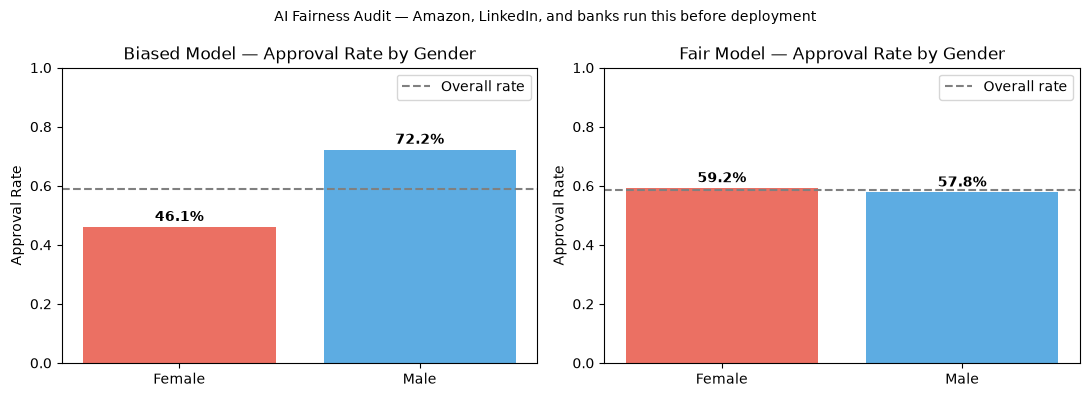


✅ Removing the gender feature reduces disparity significantly.
Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.


In [5]:
# WHAT/WHY: the audit regulators expect — quantify demographic disparity
# before and after mitigation; this is the evidence a GDPR/AI-Act file needs.
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

# ── Synthetic loan approval dataset with bias ──────────────────────────────
# Features: [income, credit_score, gender(0=F,1=M)]
n = 1000
income       = np.random.normal(50000, 15000, n)
credit_score = np.random.normal(650, 80, n)
gender       = np.random.randint(0, 2, n)  # 0=Female, 1=Male

# Introduce BIAS: same income/credit but men approved more often historically
# centered features so approvals are genuinely uncertain (~50%) instead of saturating at "approve everyone"
prob_approve = 1 / (1 + np.exp(-(
    0.00002*(income - 50000) + 0.02*(credit_score - 650) - 0.2 + 0.9*gender  # ← 0.9*gender = bias!
)))
approved = (np.random.rand(n) < prob_approve).astype(int)

X = np.column_stack([income, credit_score, gender])
X_biased  = X.copy()                        # includes gender
X_fair    = X[:, :2]                         # removes gender

# ── Train two models: biased and fair ──────────────────────────────────────
m_biased = LogisticRegression().fit(X_biased, approved)
m_fair   = LogisticRegression().fit(X_fair,   approved)

# ── Measure approval rates by gender ──────────────────────────────────────
for model_name, model, feats in [("Biased model", m_biased, X_biased),
                                   ("Fair model",   m_fair,   X_fair)]:
    pred = model.predict(feats)
    rate_f = pred[gender==0].mean()
    rate_m = pred[gender==1].mean()
    print(f"{model_name:15s} — Female approval: {rate_f:.1%}  Male approval: {rate_m:.1%}  "
          f"Disparity: {abs(rate_m-rate_f):.1%}")

# ── Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model, feats) in zip(axes, [("Biased", m_biased, X_biased), ("Fair", m_fair, X_fair)]):
    pred = model.predict(feats)
    rates = [pred[gender==g].mean() for g in [0,1]]
    bars = ax.bar(['Female','Male'], rates, color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_ylim(0,1); ax.set_title(f"{name} Model — Approval Rate by Gender")
    ax.axhline(pred.mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel("Approval Rate")
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, rate+0.02, f"{rate:.1%}", ha='center', fontweight='bold')
plt.suptitle("AI Fairness Audit — Amazon, LinkedIn, and banks run this before deployment", fontsize=10)
plt.tight_layout(); plt.show()

print("\n✅ Removing the gender feature reduces disparity significantly.")
print("Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.")

## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act (2024) — [Official Text](https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:52021PC0206)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://airc.nist.gov/RMF)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)

**State-of-the-Art:** The EU AI Act (2024) is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.

## 📝 Summary

In this notebook you applied **GDPR requirements to a working ML pipeline**:

- **Consent (Art. 6/7):** filtered training data to consented records only
- **Data minimization (Art. 5):** dropped PII columns and pseudonymized identities before training
- **Right to erasure (Art. 17):** deleted a customer on request, verified removal, and retrained
- **Automated decisions (Art. 22):** produced a per-decision feature-contribution explanation
- Ran an **automated compliance check** computed from the pipeline's actual state, and a
  **fairness audit** measuring approval-rate disparity by group

**Key takeaway:** compliance is not paperwork bolted on afterwards — each article maps to a
concrete, testable step in the pipeline.